# Employee Attrition Prediction: Exploratory Data Analysis (EDA)

#### Project Goal

The purpose of this phase is to explore the IBM HR Analytics dataset to identify patterns, relationships, and factors associated with employee attrition. The insights obtained will guide feature engineering and model development while providing actionable recommendations to improve employee retention

#### Introduction
In this project, EDA aims to identify factors influencing employee attrition and provide data-driven insights to support retention strategies.

#### Import Libraries

In [44]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [45]:
# Loading the clean dataset
df = pd.read_csv("clean_employee_attrition.csv")

#### Exploration of Numerical Features

In [46]:
# To define the numerical columns

numerical_cols = ['Age','DailyRate','DistanceFromHome','HourlyRate','MonthlyIncome','MonthlyRate','NumCompaniesWorked','PercentSalaryHike','TotalWorkingYears','TrainingTimesLastYear','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']

In [47]:
# Descriptive Statistics

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0
MonthlyRate,1470.0,14313.103401,7117.786044,2094.0,8047.0,14235.5,20461.50,26999.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.00,9.0
PercentSalaryHike,1470.0,15.209524,3.659938,11.0,12.0,14.0,18.00,25.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.00,40.0
TrainingTimesLastYear,1470.0,2.799320,1.289271,0.0,2.0,3.0,3.00,6.0


In [48]:
# Missing Values

df[numerical_cols].isnull().sum()

Age                        0
DailyRate                  0
DistanceFromHome           0
HourlyRate                 0
MonthlyIncome              0
MonthlyRate                0
NumCompaniesWorked         0
PercentSalaryHike          0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsInCurrentRole         0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

#### Distribution Analysis

In [49]:
def plot_distribution(df, columns):

    for col in columns:

        fig, ax = plt.subplots(1,2, figsize=(12,4))

        sns.histplot(df[col], kde=True, ax=ax[0])

        ax[0].set_title(f'{col} Distribution')

        sns.boxplot(x=df[col], ax=ax[1])

        ax[1].set_title(f'{col} Boxplot')

        plt.tight_layout()

        plt.show()

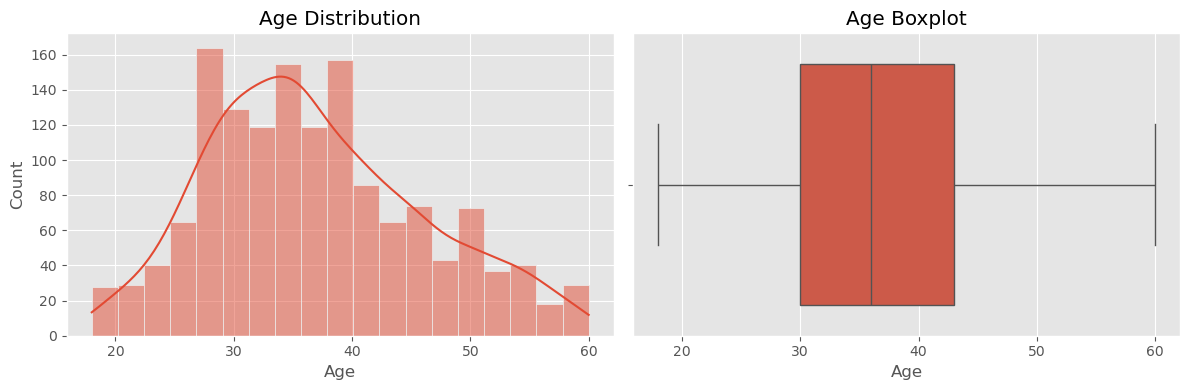

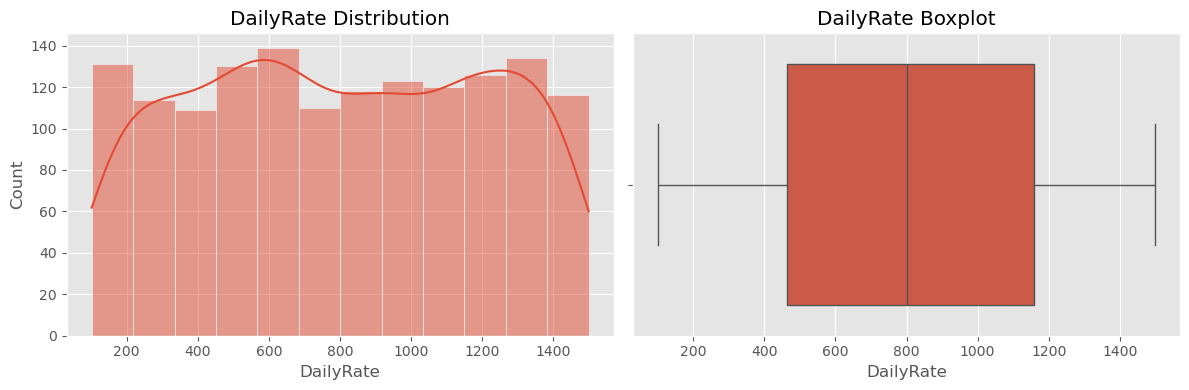

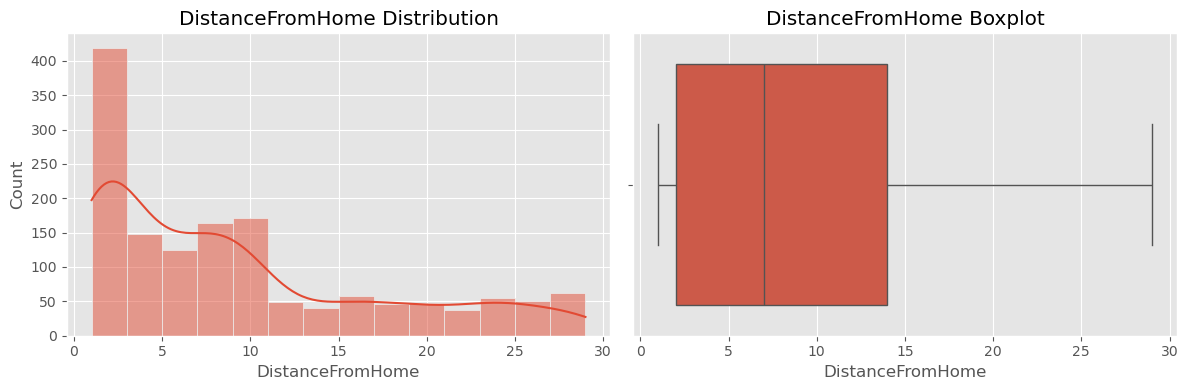

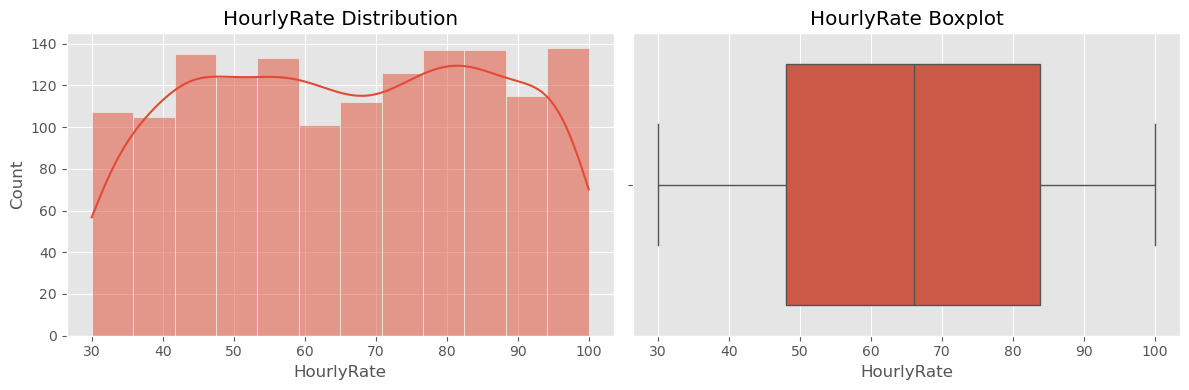

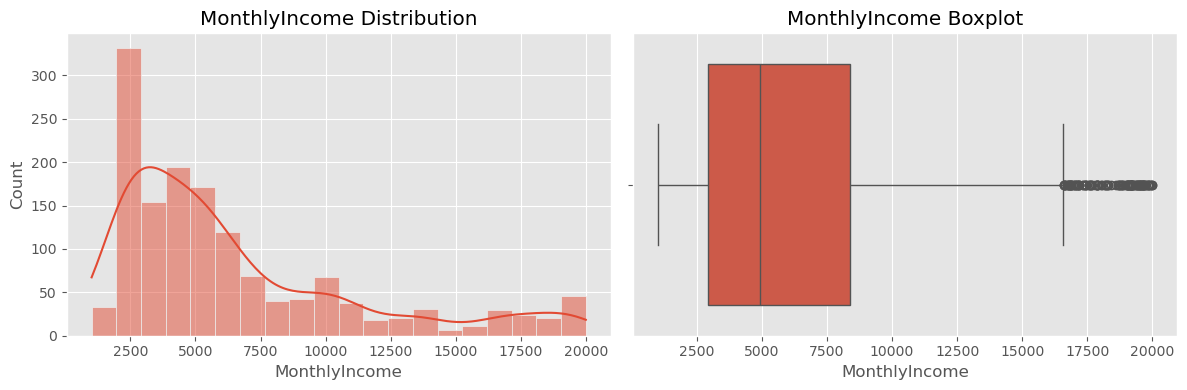

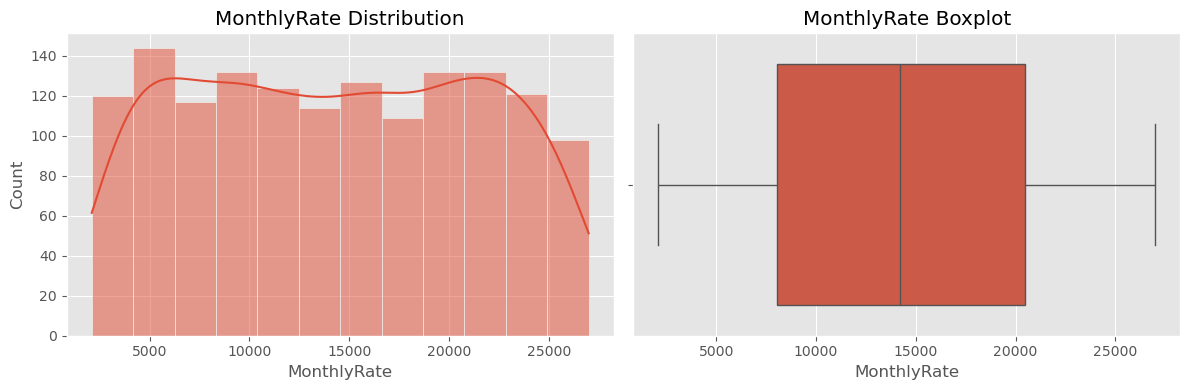

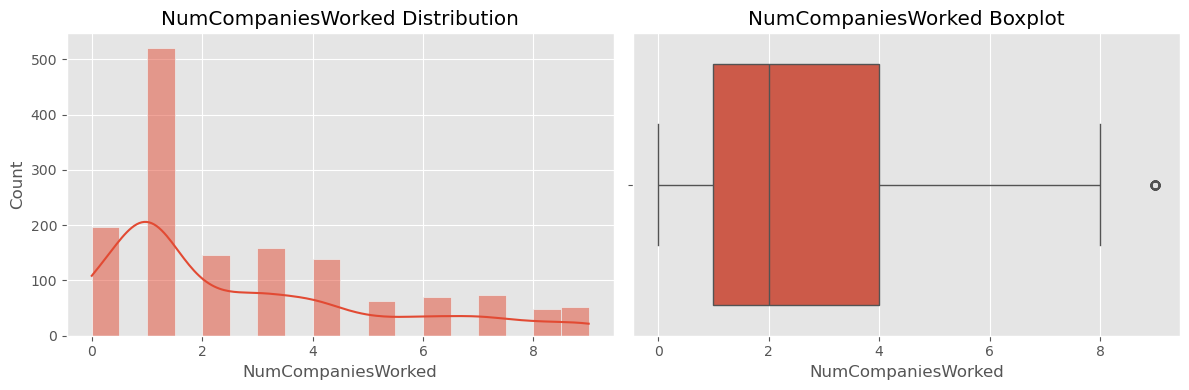

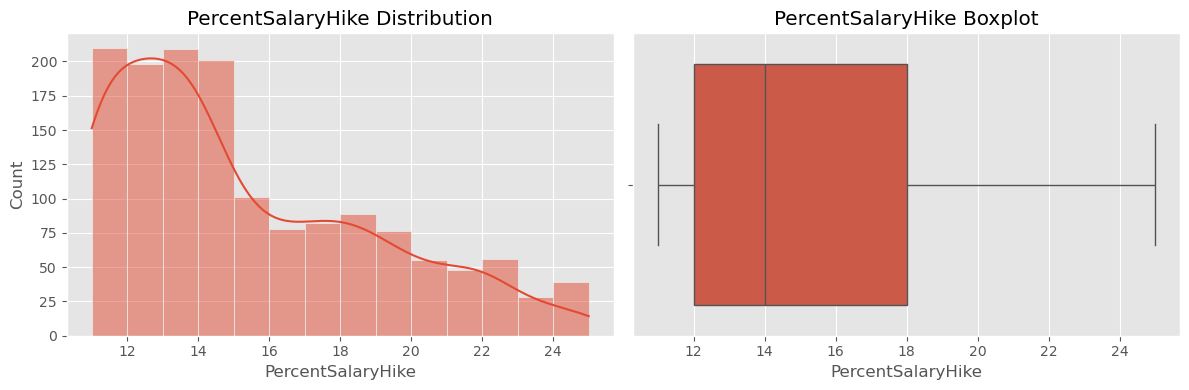

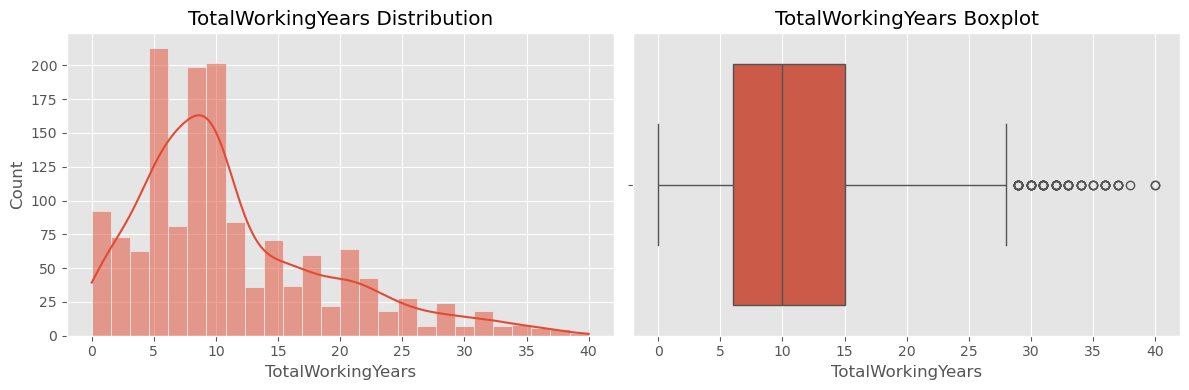

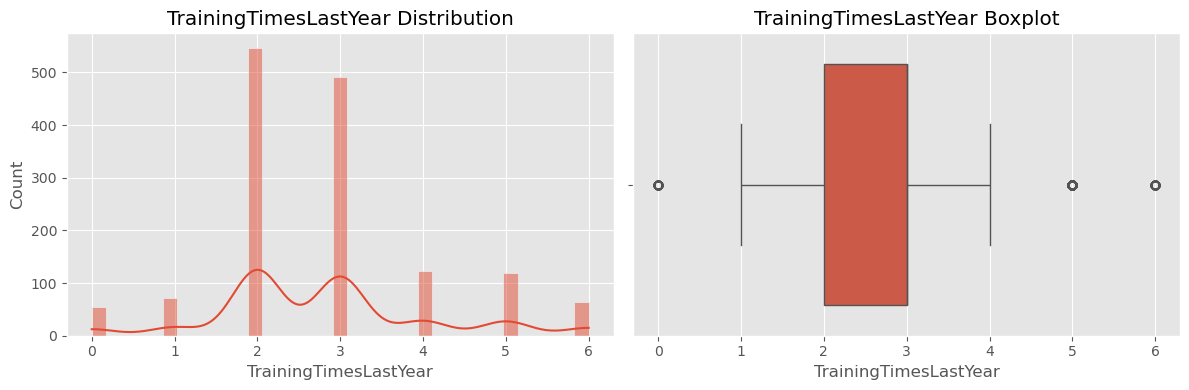

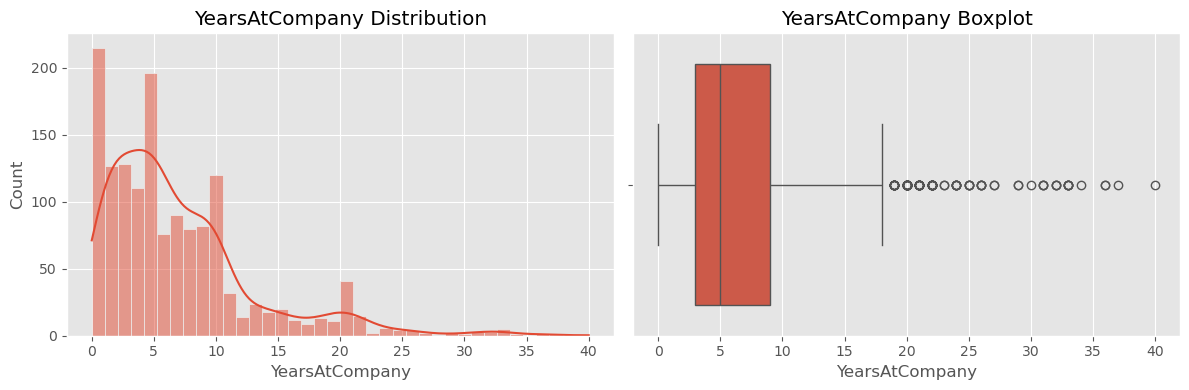

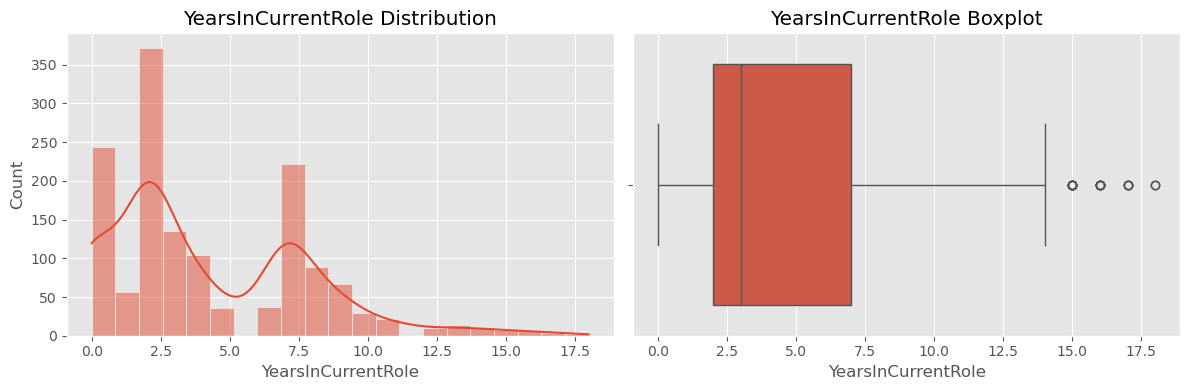

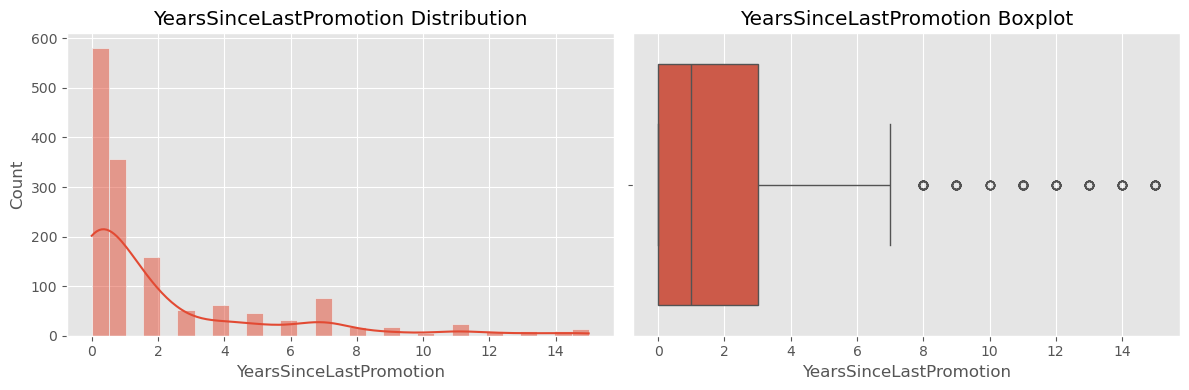

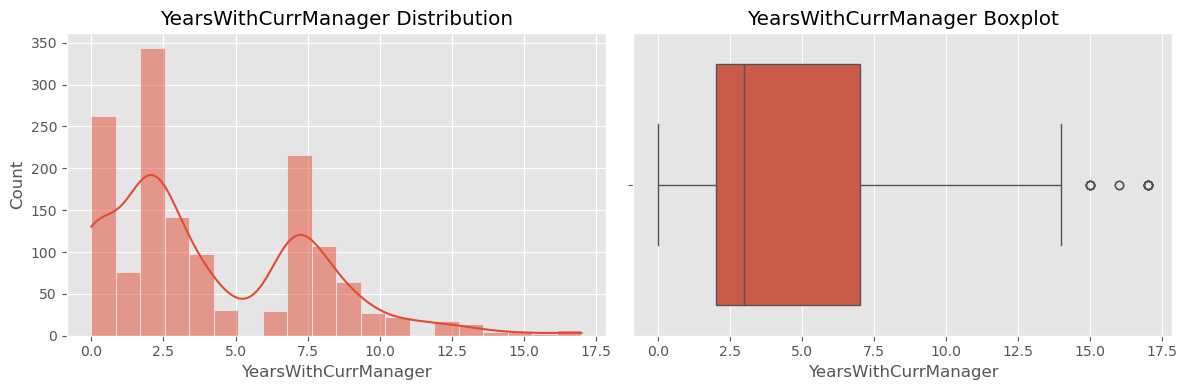

In [50]:
plot_distribution(df, numerical_cols)

#### Numerical Variables vs Attrition

In [51]:
def numerical_vs_attrition(df, columns):

    for col in columns:

        plt.figure(figsize=(7,4))

        sns.boxplot(
            data=df,
            x='Attrition',
            y=col
        )

        plt.title(f'{col} vs Attrition')

        plt.show()

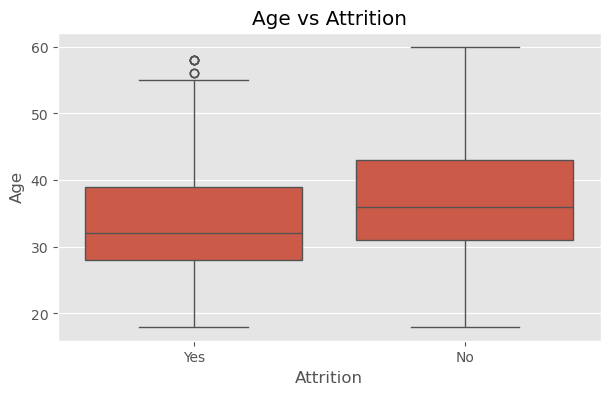

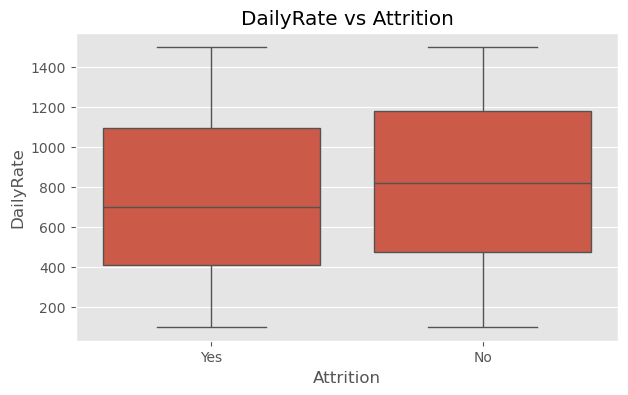

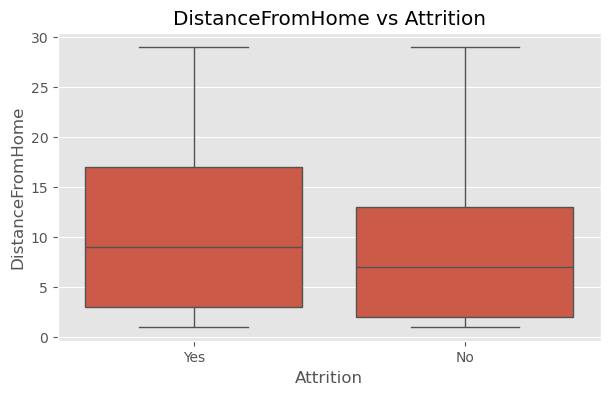

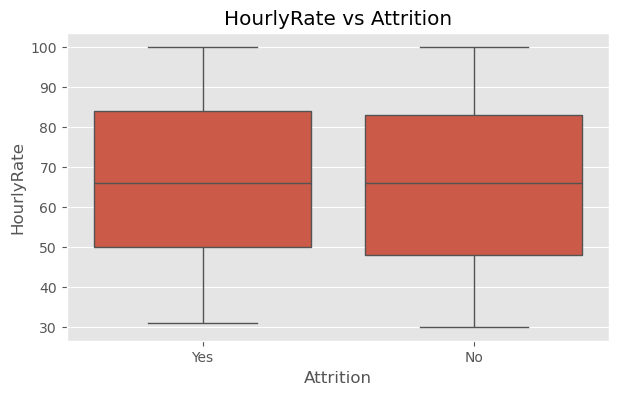

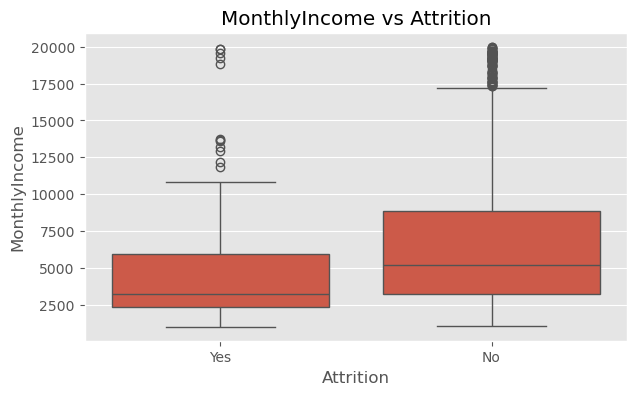

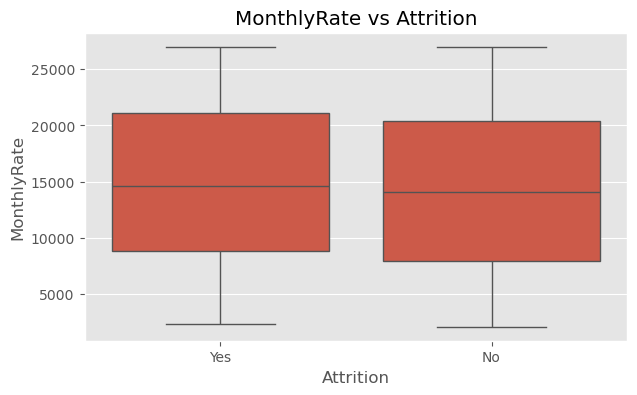

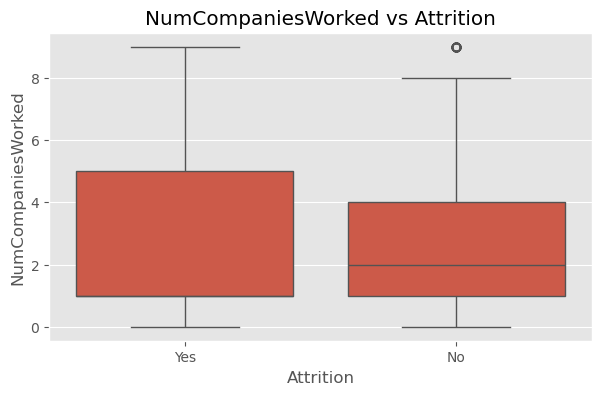

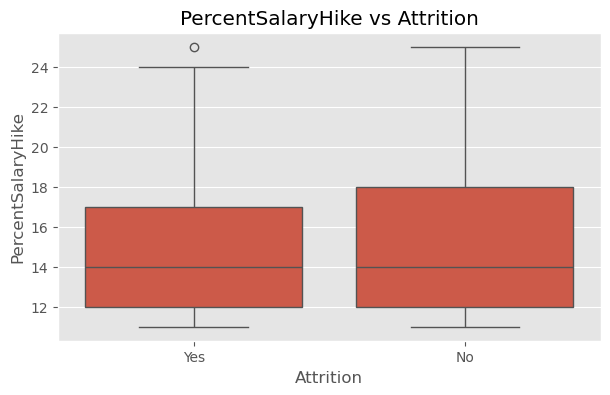

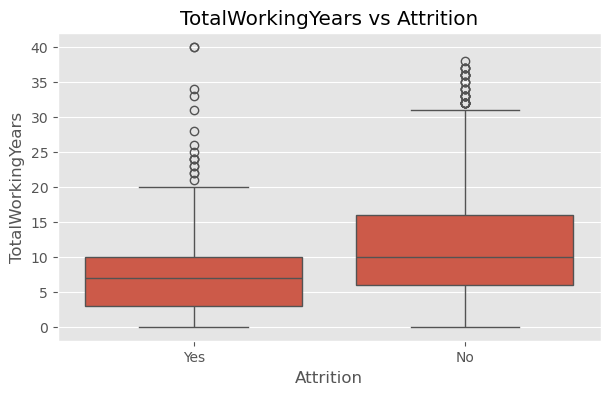

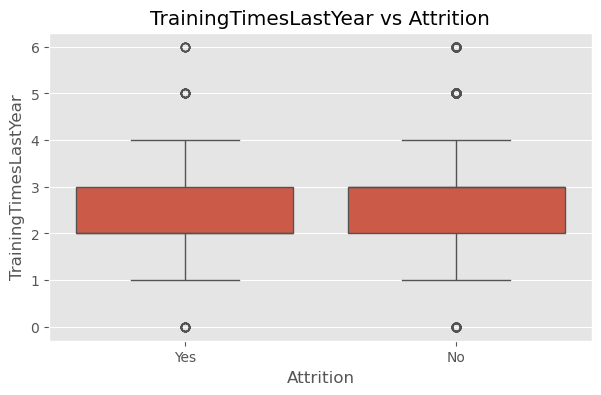

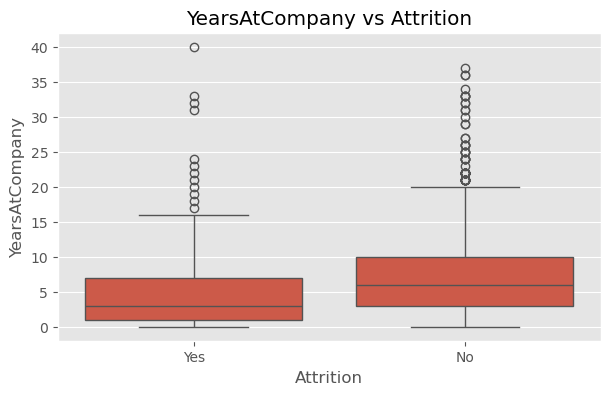

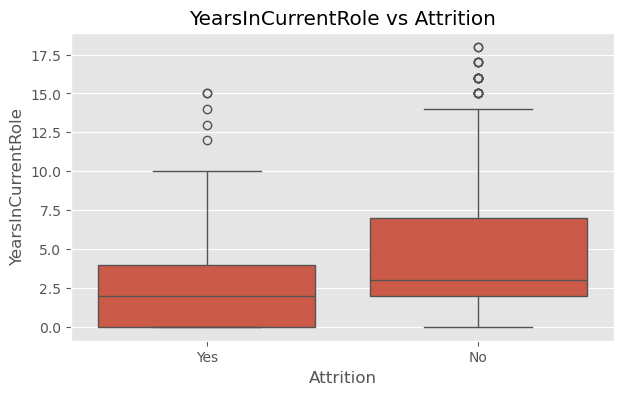

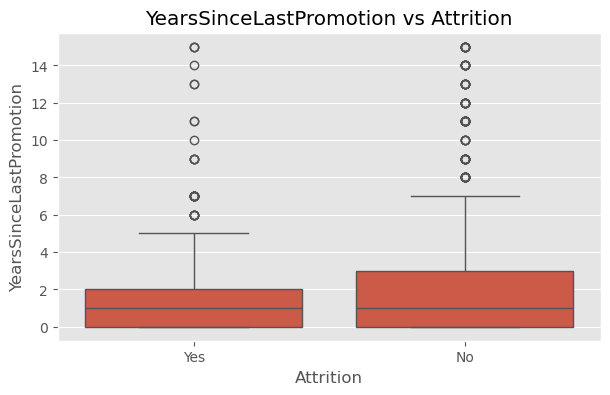

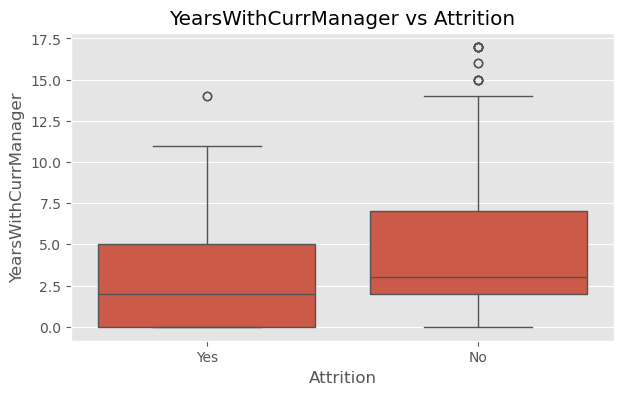

In [52]:
numerical_vs_attrition(df, numerical_cols)

#### Statistical Test
To validate relationships between variables rather than relying only on visualizations.

In [53]:
from scipy.stats import ttest_ind

In [54]:
def ttest_attrition(df, columns):

    stayed = df[df['Attrition']=='No']

    left = df[df['Attrition']=='Yes']

    results=[]

    for col in columns:

        stat,p = ttest_ind(
            stayed[col],
            left[col]
        )

        results.append([col,p])

    return pd.DataFrame(
        results,
        columns=['Variable','P-value']
    ).sort_values('P-value')

In [55]:
ttest_attrition(df,numerical_cols)

,Variable,P-value
8,TotalWorkingYears,4.061878e-11
11,YearsInCurrentRole,6.003186e-10
4,MonthlyIncome,7.147364e-10
0,Age,8.356308e-10
13,YearsWithCurrManager,1.736987e-09
10,YearsAtCompany,2.318872e-07
2,DistanceFromHome,2.793060e-03
9,TrainingTimesLastYear,2.257850e-02
1,DailyRate,2.985816e-02
6,NumCompaniesWorked,9.552526e-02


#### Exploration of Categorical Features

In [56]:
categorical_cols = ['BusinessTravel', 'Department', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']

In [57]:
# Frequency Tables

for col in categorical_cols:

    display(df[col].value_counts())

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Education
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

EnvironmentSatisfaction
3    453
4    446
2    287
1    284
Name: count, dtype: int64

...

OverTime
No     1054
Yes     416
Name: count, dtype: int64

PerformanceRating
3    1244
4     226
Name: count, dtype: int64

RelationshipSatisfaction
3    459
4    432
2    303
1    276
Name: count, dtype: int64

StockOptionLevel
0    631
1    596
2    158
3     85
Name: count, dtype: int64

WorkLifeBalance
3    893
2    344
4    153
1     80
Name: count, dtype: int64

In [58]:
def categorical_plot(df, columns):

    for col in columns:

        plt.figure(figsize=(7,4))

        sns.countplot(
            data=df,
            x=col,
            order=df[col].value_counts().index
        )

        plt.xticks(rotation=45)

        plt.title(col)

        plt.show()

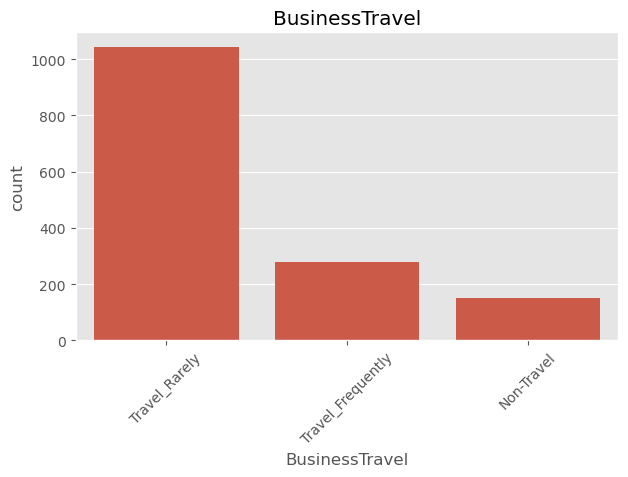

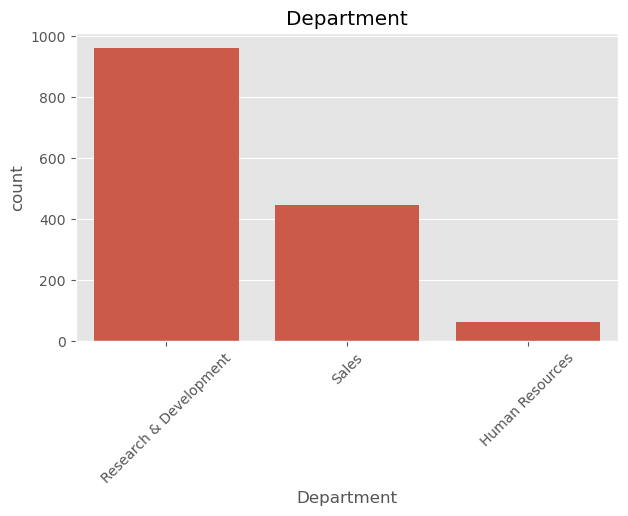

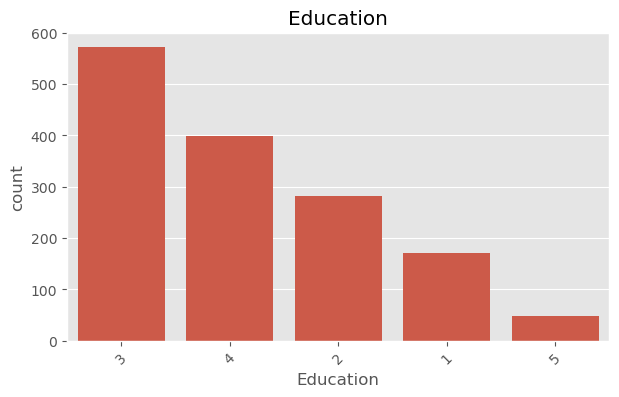

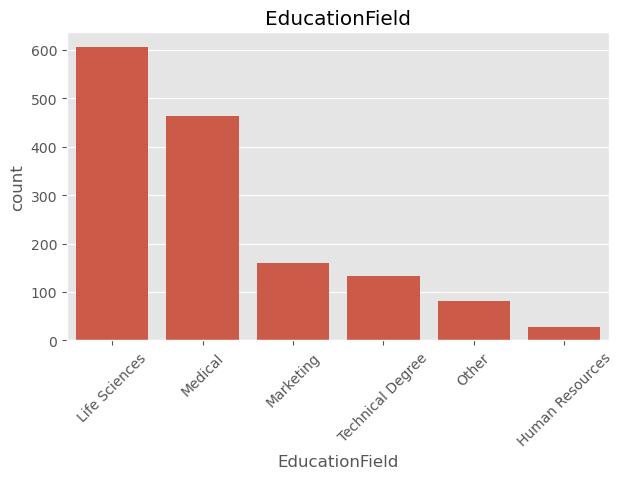

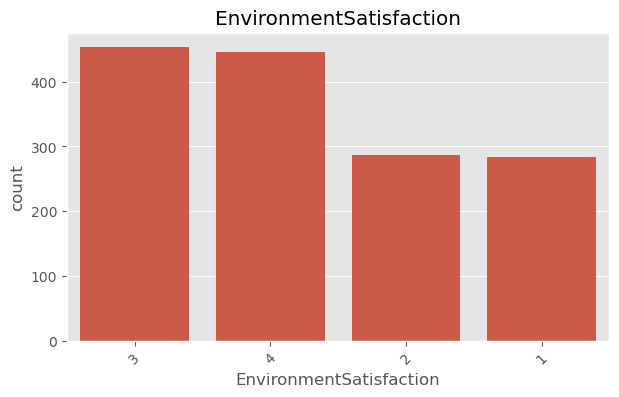

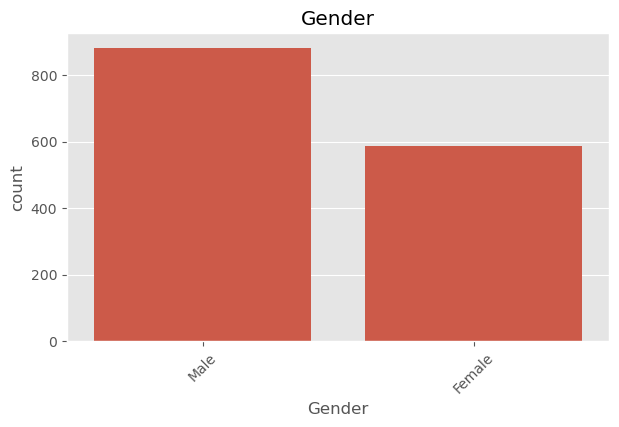

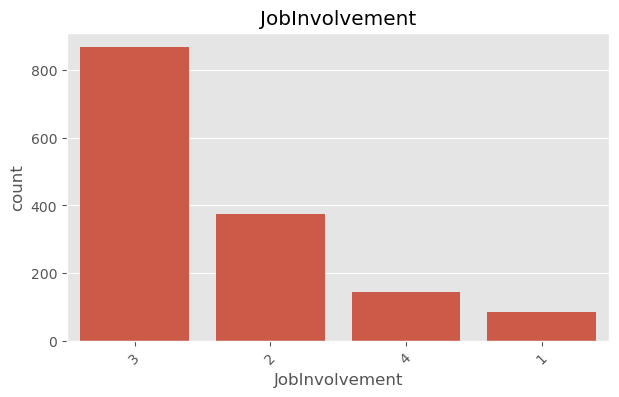

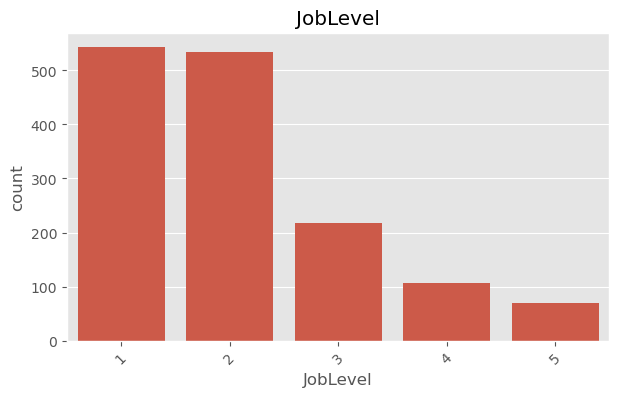

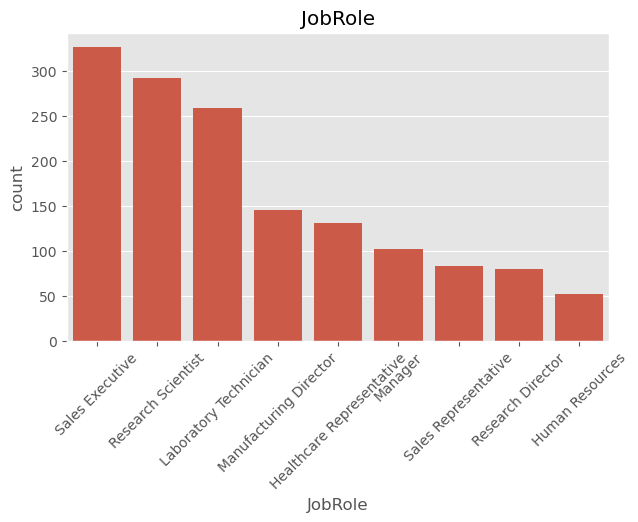

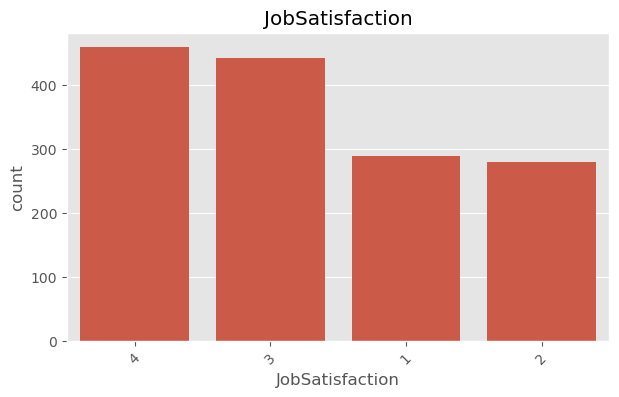

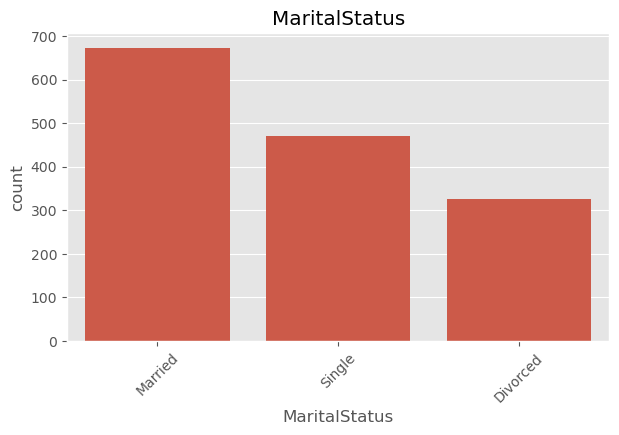

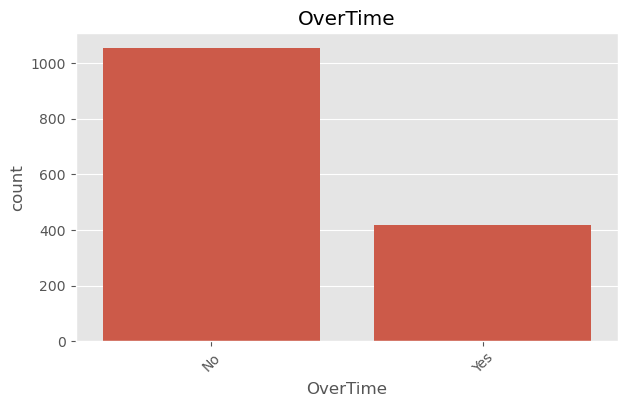

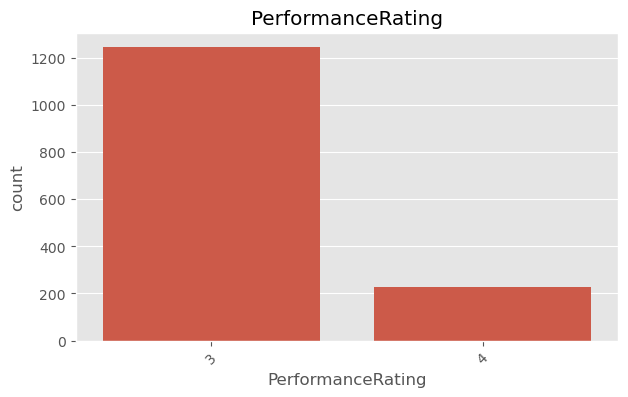

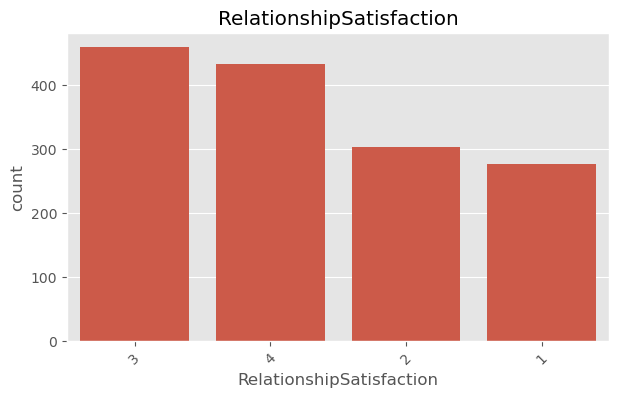

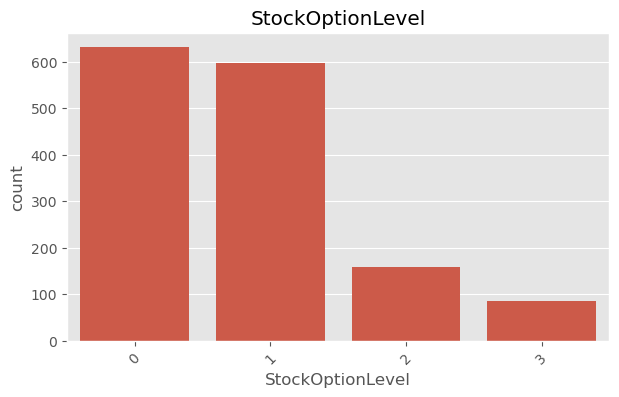

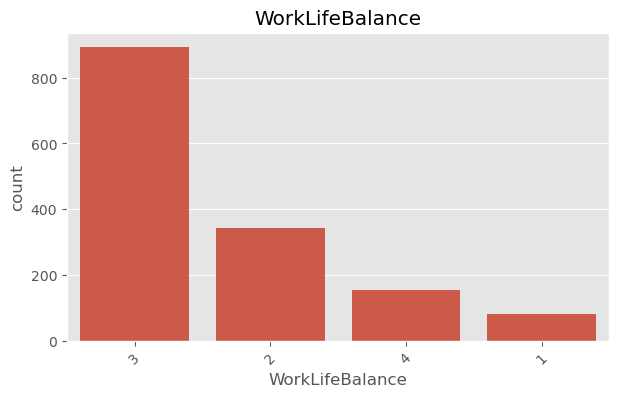

In [59]:
categorical_plot(df,categorical_cols)

In [60]:
# Percentage Table

for col in categorical_cols:

    print(col)

    display(df[col].value_counts(normalize=True).mul(100).round(2))

BusinessTravel


BusinessTravel
Travel_Rarely        70.95
Travel_Frequently    18.84
Non-Travel           10.20
Name: proportion, dtype: float64

Department


Department
Research & Development    65.37
Sales                     30.34
Human Resources            4.29
Name: proportion, dtype: float64

Education


...

RelationshipSatisfaction
3    31.22
4    29.39
2    20.61
1    18.78
Name: proportion, dtype: float64

StockOptionLevel


StockOptionLevel
0    42.93
1    40.54
2    10.75
3     5.78
Name: proportion, dtype: float64

WorkLifeBalance


WorkLifeBalance
3    60.75
2    23.40
4    10.41
1     5.44
Name: proportion, dtype: float64

#### Chi-square Test

To determine whether two categorical variables are related, and also identify which categorical features have a significant association with the target variable.

In [61]:
from scipy.stats import chi2_contingency

In [62]:
def chi_square_test(df, columns):

    results=[]

    for col in columns:

        table=pd.crosstab(df[col],df['Attrition'])

        chi2,p,dof,expected=chi2_contingency(table)

        results.append([col,p])

    return pd.DataFrame(results,columns=['Variable','P-value']).sort_values('P-value')

In [63]:
chi_square_test(df,categorical_cols)

,Variable,P-value
11,OverTime,8.158424e-21
8,JobRole,2.752482e-15
7,JobLevel,6.634685e-15
14,StockOptionLevel,4.379390e-13
10,MaritalStatus,9.455511e-11
6,JobInvolvement,2.863181e-06
0,BusinessTravel,5.608614e-06
4,EnvironmentSatisfaction,5.123469e-05
9,JobSatisfaction,5.563005e-04
15,WorkLifeBalance,9.725699e-04


#### Attrition Analysis

In [64]:
def attrition_analysis(df, columns):

    for col in columns:

        plt.figure(figsize=(7,4))

        sns.countplot(

            data=df,

            x=col,

            hue='Attrition'

        )

        plt.xticks(rotation=45)

        plt.title(f'Attrition by {col}')

        plt.show()

        display(

            pd.crosstab(

                df[col],

                df['Attrition'],

                normalize='index'

            )*100

        )

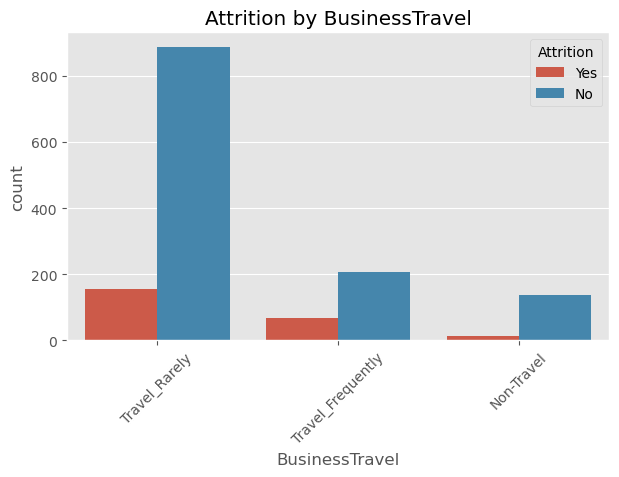

Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.000000,8.000000
Travel_Frequently,75.090253,24.909747
Travel_Rarely,85.043145,14.956855


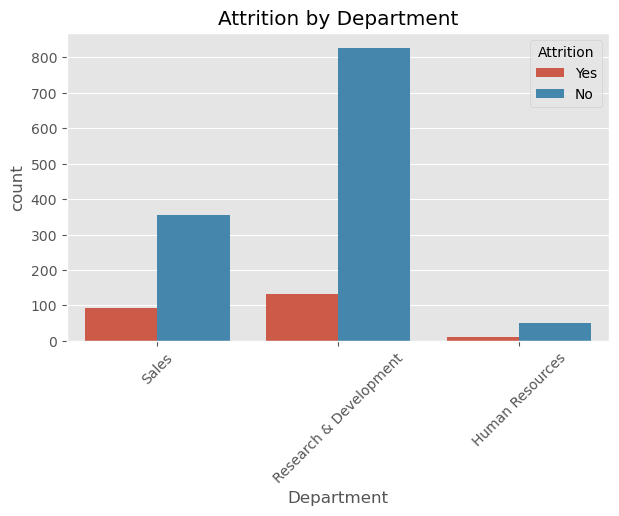

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


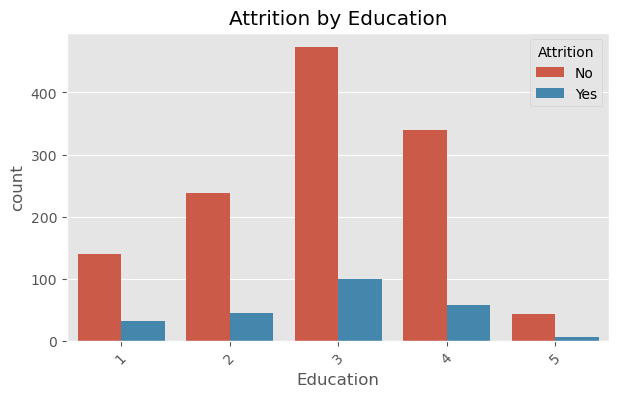

Attrition,No,Yes
Education,,
1,81.764706,18.235294
2,84.397163,15.602837
3,82.692308,17.307692
4,85.427136,14.572864
5,89.583333,10.416667


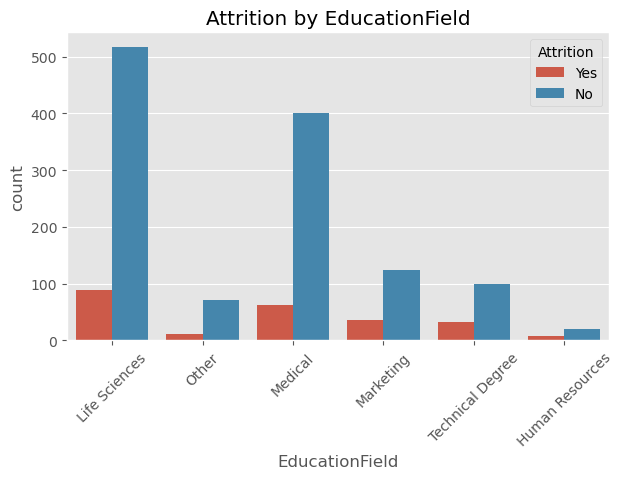

Attrition,No,Yes
EducationField,,
Human Resources,74.074074,25.925926
Life Sciences,85.313531,14.686469
Marketing,77.987421,22.012579
Medical,86.422414,13.577586
Other,86.585366,13.414634
Technical Degree,75.757576,24.242424


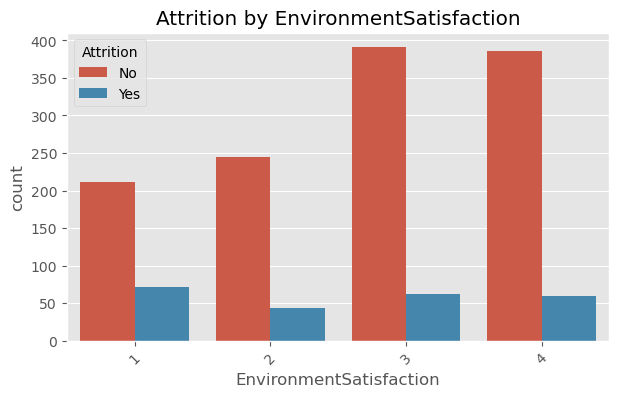

Attrition,No,Yes
EnvironmentSatisfaction,,
1,74.647887,25.352113
2,85.017422,14.982578
3,86.313466,13.686534
4,86.547085,13.452915


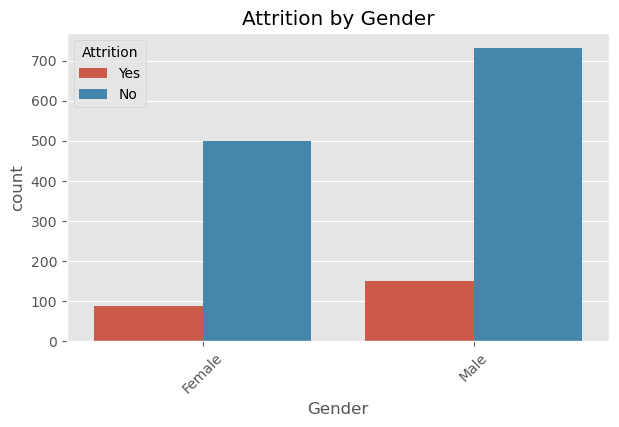

Attrition,No,Yes
Gender,,
Female,85.204082,14.795918
Male,82.993197,17.006803


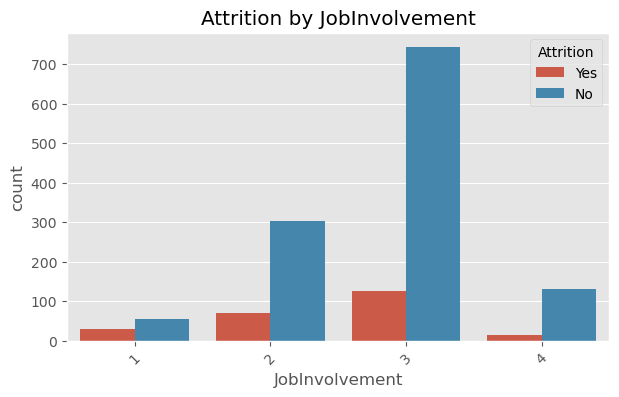

Attrition,No,Yes
JobInvolvement,,
1,66.265060,33.734940
2,81.066667,18.933333
3,85.599078,14.400922
4,90.972222,9.027778


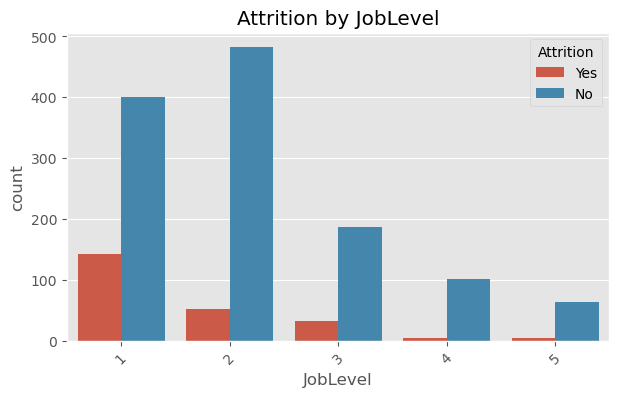

Attrition,No,Yes
JobLevel,,
1,73.664825,26.335175
2,90.262172,9.737828
3,85.321101,14.678899
4,95.283019,4.716981
5,92.753623,7.246377


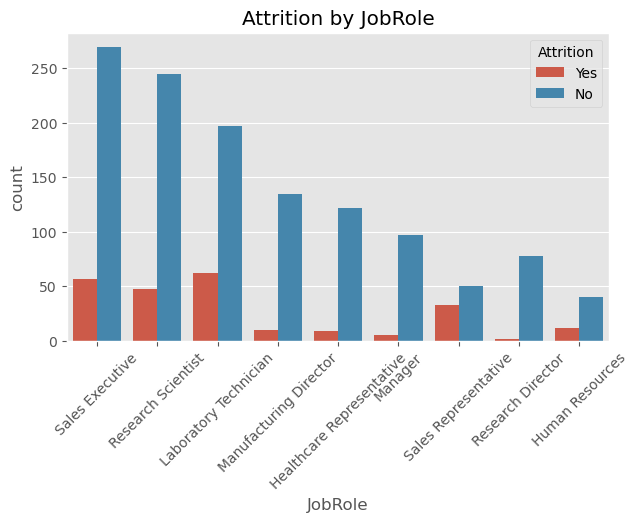

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


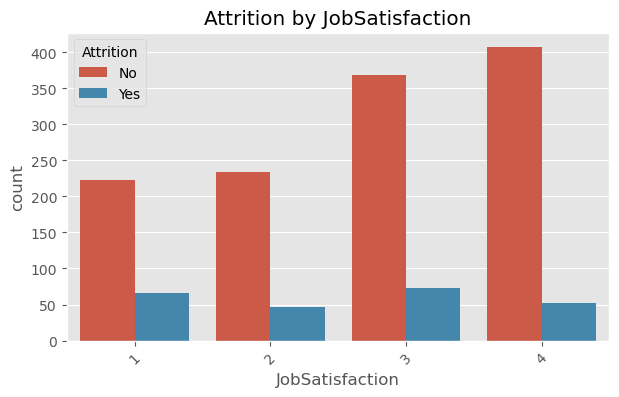

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


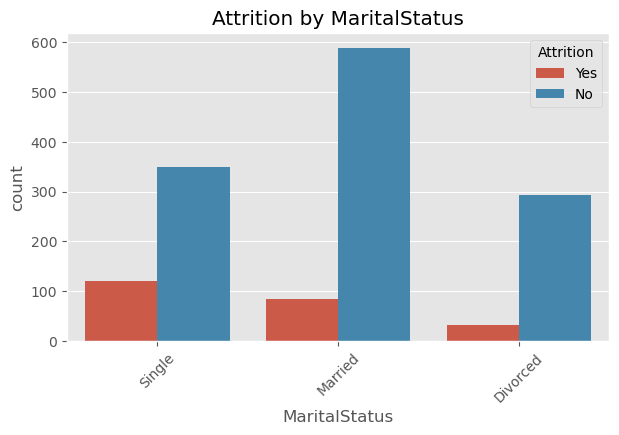

Attrition,No,Yes
MaritalStatus,,
Divorced,89.908257,10.091743
Married,87.518574,12.481426
Single,74.468085,25.531915


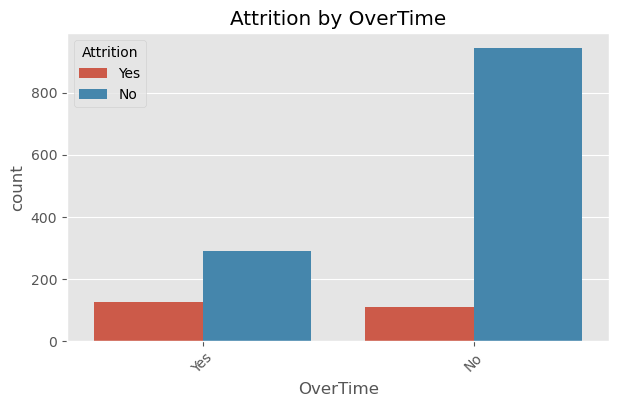

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


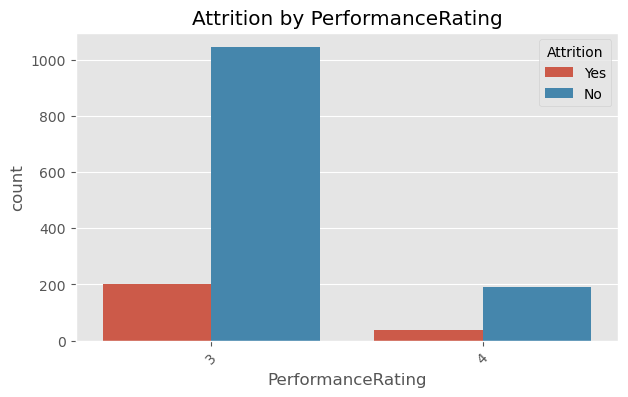

Attrition,No,Yes
PerformanceRating,,
3,83.922830,16.077170
4,83.628319,16.371681


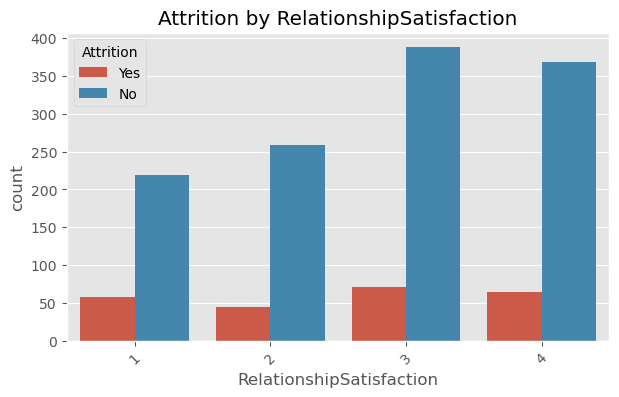

Attrition,No,Yes
RelationshipSatisfaction,,
1,79.347826,20.652174
2,85.148515,14.851485
3,84.531590,15.468410
4,85.185185,14.814815


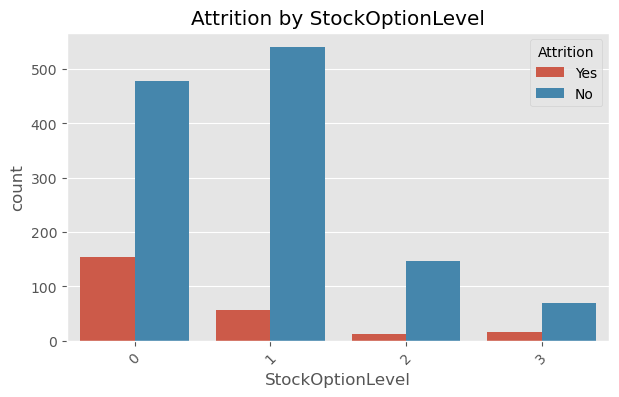

Attrition,No,Yes
StockOptionLevel,,
0,75.594295,24.405705
1,90.604027,9.395973
2,92.405063,7.594937
3,82.352941,17.647059


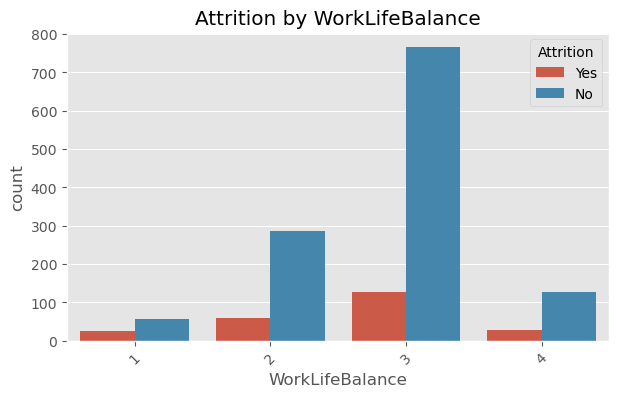

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


In [65]:
attrition_analysis(df,categorical_cols)

#### Pairplot of High-Impact Variables

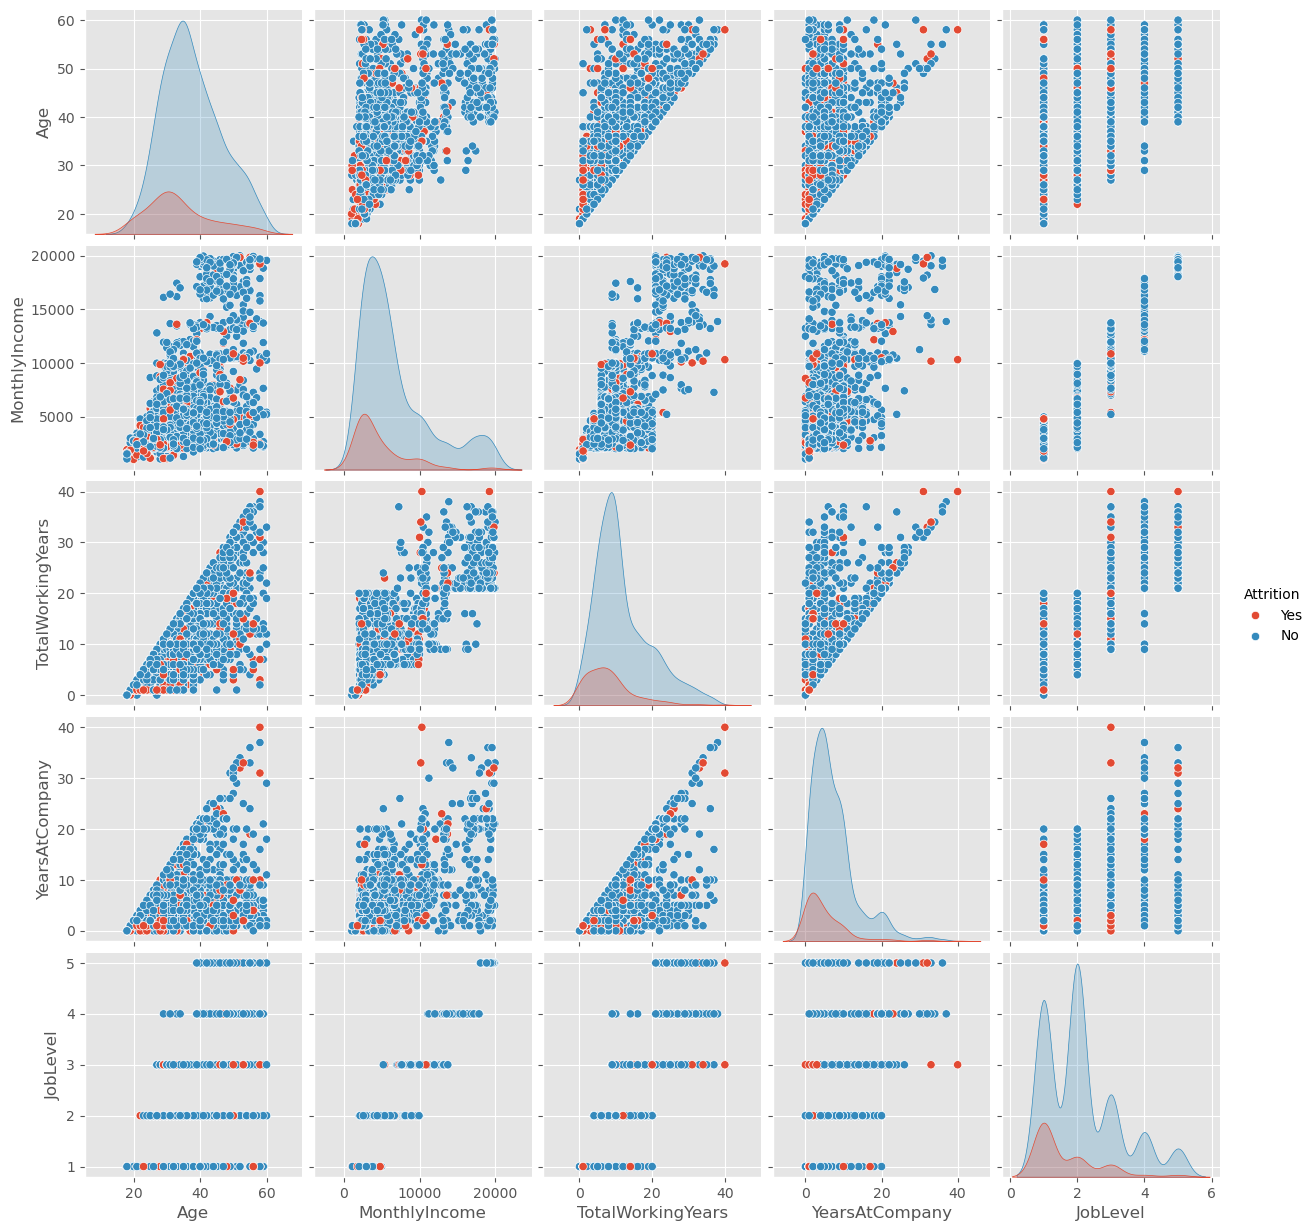

In [66]:
pairplot_cols = ['Age','MonthlyIncome','TotalWorkingYears','YearsAtCompany','JobLevel','Attrition']

sns.pairplot(df[pairplot_cols],hue='Attrition',diag_kind='kde')

plt.show()

This visualizes relationships among the variables most likely to influence attrition.

#### Attrition Rate (%) for Every Categorical Variable

In [67]:
categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'StockOptionLevel']

In [68]:
for col in categorical_cols:

    print(f"\n{'='*60}")
    print(col)
    print('='*60)

    attrition_rate = (pd.crosstab(df[col], df['Attrition'], normalize='index') *100).round(2)

    display(attrition_rate.sort_values('Yes', ascending=False))


BusinessTravel


Attrition,No,Yes
BusinessTravel,,
Travel_Frequently,75.09,24.91
Travel_Rarely,85.04,14.96
Non-Travel,92.00,8.00



Department


Attrition,No,Yes
Department,,
Sales,79.37,20.63
Human Resources,80.95,19.05
Research & Development,86.16,13.84



EducationField


...

Attrition,No,Yes
WorkLifeBalance,,
1,68.75,31.25
4,82.35,17.65
2,83.14,16.86
3,85.78,14.22



JobInvolvement


Attrition,No,Yes
JobInvolvement,,
1,66.27,33.73
2,81.07,18.93
3,85.60,14.40
4,90.97,9.03



StockOptionLevel


Attrition,No,Yes
StockOptionLevel,,
0,75.59,24.41
3,82.35,17.65
1,90.60,9.40
2,92.41,7.59


### Statistical Significance Analysis: Numerical Variables

To complement the visual analysis, statistical hypothesis tests are used to determine whether observed differences between employees who stayed and those who left are statistically significant.

For numerical variables, an independent two-sample t-test is used. The null hypothesis assumes that there is no significant difference in the mean of a numerical variable between employees who stayed and employees who left.

A p-value below 0.05 is considered statistically significant.

In [72]:
# To import the test

from scipy.stats import ttest_ind

In [73]:
ttest_results = []

for col in numerical_cols:
    
    stayed = df.loc[df['Attrition'] == 'No', col]
    left = df.loc[df['Attrition'] == 'Yes', col]
    
    t_stat, p_value = ttest_ind(stayed,left,equal_var=False)
    
    ttest_results.append({'Variable': col,'Stayed Mean': stayed.mean(),'Left Mean': left.mean(),'Mean Difference': left.mean() - stayed.mean(),
    'T-statistic': t_stat,'P-value': p_value})

ttest_results = pd.DataFrame(ttest_results)

ttest_results['Significant'] = np.where(ttest_results['P-value'] < 0.05,'Yes','No')

ttest_results = ttest_results.sort_values('P-value')

ttest_results.round(4)

,Variable,Stayed Mean,Left Mean,Mean Difference,T-statistic,P-value,Significant
4,MonthlyIncome,6832.7397,4787.0928,-2045.6468,7.4826,0.0000,Yes
8,TotalWorkingYears,11.8629,8.2447,-3.6182,7.0192,0.0000,Yes
11,YearsInCurrentRole,4.4842,2.9030,-1.5812,6.8471,0.0000,Yes
13,YearsWithCurrManager,4.3674,2.8523,-1.5151,6.6334,0.0000,Yes
0,Age,37.5612,33.6076,-3.9536,5.8280,0.0000,Yes
10,YearsAtCompany,7.3690,5.1308,-2.2382,5.2826,0.0000,Yes
2,DistanceFromHome,8.9157,10.6329,1.7173,-2.8882,0.0041,Yes
9,TrainingTimesLastYear,2.8329,2.6245,-0.2085,2.3305,0.0204,Yes
1,DailyRate,812.5045,750.3629,-62.1416,2.1789,0.0300,Yes
6,NumCompaniesWorked,2.6456,2.9409,0.2953,-1.5747,0.1163,No


#### To show only statistically significant variables

In [74]:

significant_numerical = ttest_results[ttest_results['P-value'] < 0.05]

significant_numerical.round(4)

,Variable,Stayed Mean,Left Mean,Mean Difference,T-statistic,P-value,Significant
4,MonthlyIncome,6832.7397,4787.0928,-2045.6468,7.4826,0.0000,Yes
8,TotalWorkingYears,11.8629,8.2447,-3.6182,7.0192,0.0000,Yes
11,YearsInCurrentRole,4.4842,2.9030,-1.5812,6.8471,0.0000,Yes
13,YearsWithCurrManager,4.3674,2.8523,-1.5151,6.6334,0.0000,Yes
0,Age,37.5612,33.6076,-3.9536,5.8280,0.0000,Yes
10,YearsAtCompany,7.3690,5.1308,-2.2382,5.2826,0.0000,Yes
2,DistanceFromHome,8.9157,10.6329,1.7173,-2.8882,0.0041,Yes
9,TrainingTimesLastYear,2.8329,2.6245,-0.2085,2.3305,0.0204,Yes
1,DailyRate,812.5045,750.3629,-62.1416,2.1789,0.0300,Yes


### Statistical Findings: Numerical Variables

An independent two-sample t-test was conducted to determine whether the numerical characteristics of employees who stayed with the organization differed significantly from those who left. A significance level of 0.05 was used.

The analysis identified several numerical variables with statistically significant differences between the two groups.

#### Key Observations

- **Monthly Income:** Employees who stayed had a substantially higher average monthly income (6,832.74) than employees who left (4,787.09), representing an average difference of approximately 2,045.65.

- **Total Working Years:** Employees who stayed had more total work experience on average (11.86 years) compared with employees who left (8.24 years).

- **Years in Current Role:** Employees who stayed had spent longer in their current roles (4.48 years) than employees who left (2.90 years).

- **Years with Current Manager:** Employees who stayed had spent more time with their current managers (4.36 years) compared with those who left (2.85 years).

- **Age:** Employees who stayed were older on average (37.56 years) than employees who left (33.61 years), suggesting that younger employees may have a higher tendency to leave.

- **Years at Company:** Employees who stayed had longer organizational tenure (7.37 years) compared with employees who left (5.13 years).

- **Distance from Home:** Employees who left lived farther from the workplace on average (10.63) than employees who stayed (8.92).

- **Training Times Last Year:** Employees who stayed received slightly more training on average (2.83) than employees who left (2.62). Although statistically significant, the difference is relatively small.

- **Daily Rate:** Employees who stayed had a higher average daily rate (812.50) than employees who left (750.36).

### Statistical Interpretation

The results indicate that employee attrition is significantly associated with several aspects of employee demographics, compensation, experience, tenure, and workplace proximity. The strongest differences in mean values were observed for Monthly Income, Total Working Years, Age, and Years at Company. These variables may therefore warrant further investigation during the subsequent modelling stages.

However, statistical significance does not imply causation. The t-test only establishes that the observed group differences are unlikely to have occurred by random sampling variation alone. Further analysis and machine learning models will be required to assess the predictive contribution of these variables. Hence the statistically significant variables identified in this analysis will be considered alongside categorical variables and other statistical measures before final conclusions about the strongest attrition drivers are made.

### Statistical Significance Analysis: Categorical Variables

While the t-test was used to examine differences in numerical variables, categorical variables require a different statistical approach.

The Chi-Square Test of Independence is used to determine whether there is a statistically significant association between each categorical variable and employee attrition.

The null hypothesis assumes that there is no association between the categorical variable and attrition.

A p-value below 0.05 is considered statistically significant.

In [76]:
#To import the test

from scipy.stats import chi2_contingency

In [77]:
chi_results = []

for col in categorical_cols:
    
    contingency_table = pd.crosstab(df[col],df['Attrition'])
    
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    chi_results.append({'Variable': col,'Chi-square': chi2,'P-value': p_value,'Degrees of Freedom': dof})

chi_results = pd.DataFrame(chi_results)

chi_results['Significant'] = np.where(chi_results['P-value'] < 0.05,'Yes','No')

chi_results = chi_results.sort_values('P-value')

chi_results.round(4)

,Variable,Chi-square,P-value,Degrees of Freedom,Significant
6,OverTime,87.5643,0.0000,1,Yes
4,JobRole,86.1903,0.0000,8,Yes
11,StockOptionLevel,60.5983,0.0000,3,Yes
5,MaritalStatus,46.1637,0.0000,2,Yes
10,JobInvolvement,28.4920,0.0000,3,Yes
0,BusinessTravel,24.1824,0.0000,2,Yes
7,EnvironmentSatisfaction,22.5039,0.0001,3,Yes
8,JobSatisfaction,17.5051,0.0006,3,Yes
9,WorkLifeBalance,16.3251,0.0010,3,Yes
1,Department,10.7960,0.0045,2,Yes


In [78]:
significant_categorical = chi_results[chi_results['P-value'] < 0.05]

significant_categorical.round(4)

,Variable,Chi-square,P-value,Degrees of Freedom,Significant
6,OverTime,87.5643,0.0000,1,Yes
4,JobRole,86.1903,0.0000,8,Yes
11,StockOptionLevel,60.5983,0.0000,3,Yes
5,MaritalStatus,46.1637,0.0000,2,Yes
10,JobInvolvement,28.4920,0.0000,3,Yes
0,BusinessTravel,24.1824,0.0000,2,Yes
7,EnvironmentSatisfaction,22.5039,0.0001,3,Yes
8,JobSatisfaction,17.5051,0.0006,3,Yes
9,WorkLifeBalance,16.3251,0.0010,3,Yes
1,Department,10.7960,0.0045,2,Yes


## Statistical Findings: Categorical Variables

The Chi-Square Test of Independence was conducted to determine whether categorical employee characteristics were significantly associated with employee attrition. A significance level of 0.05 was used.

The analysis found statistically significant associations between attrition and 11 of the 12 categorical variables examined. Gender was the only variable that did not show a statistically significant association with attrition (p = 0.2906).

### Key Observations

- **OverTime** showed the strongest statistical association with attrition based on the Chi-Square statistic (χ² = 87.56, p < 0.001).
- **JobRole** was also strongly associated with attrition (χ² = 86.19, p < 0.001).
- **StockOptionLevel** showed a statistically significant association with attrition (χ² = 60.60, p < 0.001).
- **MaritalStatus** was significantly associated with attrition (χ² = 45.16, p < 0.001).
- **JobInvolvement** showed a significant association with attrition (χ² = 28.49, p < 0.001).
- **BusinessTravel** was significantly associated with attrition (χ² = 24.18, p < 0.001).
- **EnvironmentSatisfaction** showed a significant association with attrition (χ² = 22.50, p < 0.001).
- **JobSatisfaction** was significantly associated with attrition (χ² = 17.51, p < 0.001).
- **WorkLifeBalance** showed a significant association with attrition (χ² = 16.33, p = 0.0010).
- **EducationField** was significantly associated with attrition (χ² = 16.02, p = 0.0068).
- **Department** also showed a statistically significant association with attrition (χ² = 10.76, p = 0.0045).

### Non-Significant Variable

**Gender** did not show a statistically significant association with employee attrition (χ² = 1.12, p = 0.2906). Therefore, based on this analysis, there is insufficient statistical evidence to conclude that attrition differs systematically by gender in this dataset.

### Statistical Interpretation

The Chi-Square analysis indicates that several aspects of an employee's work experience, job characteristics, and personal circumstances are associated with attrition.

However, the Chi-Square statistic and p-value do not indicate the strength of these relationships. A very small p-value tells us that an association is statistically significant, but it does not necessarily mean that the association is strong or practically important.

Therefore, Cramér's V will be used next to measure the strength of association between each categorical variable and employee attrition.

### Strength of Association: Cramér's V

Cramér's V is used to measure the strength of association between categorical variables and employee attrition, while the Chi-Square Test determines whether an association is statistically significant, Cramér's V provides an effect-size measure indicating how strong the association is.

Cramér's V ranges from 0 to 1:
- 0 indicates no association.
- Values closer to 1 indicate stronger associations.
For this analysis, Cramér's V will be interpreted alongside the Chi-Square p-values rather than in isolation.

In [79]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(table):
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))


cramers_results = []

for col in categorical_cols:
    
    contingency_table = pd.crosstab(df[col],df['Attrition'])
    
    v = cramers_v(contingency_table)
    
    cramers_results.append({'Variable': col,"Cramer's V": v})

cramers_results = pd.DataFrame(cramers_results)

cramers_results = cramers_results.sort_values("Cramer's V",ascending=False)

cramers_results.round(4)

,Variable,Cramer's V
6,OverTime,0.2441
4,JobRole,0.2421
11,StockOptionLevel,0.2030
5,MaritalStatus,0.1772
10,JobInvolvement,0.1392
0,BusinessTravel,0.1283
7,EnvironmentSatisfaction,0.1237
8,JobSatisfaction,0.1091
9,WorkLifeBalance,0.1054
2,EducationField,0.1044


In [80]:
cramers_results = cramers_results.merge(chi_results[['Variable', 'P-value', 'Significant']],on='Variable',how='left')

cramers_results = cramers_results.sort_values("Cramer's V",ascending=False)

cramers_results.round(4)

,Variable,Cramer's V,P-value,Significant
0,OverTime,0.2441,0.0000,Yes
1,JobRole,0.2421,0.0000,Yes
2,StockOptionLevel,0.2030,0.0000,Yes
3,MaritalStatus,0.1772,0.0000,Yes
4,JobInvolvement,0.1392,0.0000,Yes
5,BusinessTravel,0.1283,0.0000,Yes
6,EnvironmentSatisfaction,0.1237,0.0001,Yes
7,JobSatisfaction,0.1091,0.0006,Yes
8,WorkLifeBalance,0.1054,0.0010,Yes
9,EducationField,0.1044,0.0068,Yes


### Cramér's V Findings

Cramér's V was used to assess the strength of association between categorical employee characteristics and attrition after identifying statistically significant relationships using the Chi-Square Test.

The results show that **OverTime (V = 0.2441)** and **JobRole (V = 0.2421)** had the strongest associations with employee attrition among the categorical variables examined. They were followed by **StockOptionLevel (V = 0.2030)** and **MaritalStatus (V = 0.1772)**.

Other variables, including JobInvolvement, BusinessTravel, EnvironmentSatisfaction, JobSatisfaction, WorkLifeBalance, EducationField, and Department, showed weaker associations with attrition.

Gender had the weakest association (V = 0.0276) and was also not statistically significant based on the Chi-Square test (p = 0.2906).

Overall, the results suggest that no single categorical variable has a strong association with attrition on its own. However, several workplace and employee-related characteristics show statistically significant relationships with attrition. In particular, overtime, job role, stock options, and marital status warrant further investigation.

Cramér's V measures association rather than causation. Therefore, these results should be interpreted alongside attrition rates, numerical-variable analysis, and the predictive models developed in later phases.

## Key EDA Findings and Business Insights

#### 1. Compensation and Income
Employees who left the organization had a substantially lower average monthly income than employees who stayed. The average MonthlyIncome was 4,787.09 for employees who left compared with 6,832.74 for employees who stayed.

The independent t-test indicated that this difference was statistically significant (p < 0.001). This suggests that compensation may be an important factor associated with employee attrition. However, the analysis does not establish that lower income directly causes employees to leave.

#### 2. Age and Employee Experience
Employees who left were younger on average than employees who stayed. The mean age was 33.61 years among employees who left compared with 37.56 years among employees who stayed.

TotalWorkingYears also differed significantly between the two groups, with employees who stayed having an average of 11.86 years of total working experience compared with 8.24 years among employees who left. These findings suggest that younger and less experienced employees may be more vulnerable to attrition.

#### 3. Organizational Tenure
Employees who stayed had spent longer with the organization than employees who left. The average YearsAtCompany was 7.37 years for employees who stayed compared with 5.13 years for employees who left. Similarly, employees who stayed had spent more time in their current role and with their current manager. These patterns suggest that shorter organizational and role tenure is associated with higher employee attrition.

#### 4. Distance From Home
DistanceFromHome was significantly different between the two groups. Employees who left lived an average of 10.63 distance units from the workplace compared with 8.92 among employees who stayed. Although the difference was statistically significant, the magnitude of the difference was relatively modest. Therefore, distance from home should be considered as one contributing factor rather than a standalone explanation for attrition.

#### 5. Overtime
OverTime had the strongest categorical association with employee attrition based on Cramér's V (V = 0.2441) and was highly statistically significant according to the Chi-Square test (p < 0.001). This indicates that overtime status is an important area for further investigation when considering employee retention.

#### 6. Job Role
JobRole had the second strongest categorical association with attrition (Cramér's V = 0.2421, p < 0.001).
This suggests that attrition patterns differ across job roles. Differences in workload, career progression, compensation, responsibilities, or working conditions across roles may warrant further investigation.

#### 7. Stock Option Level
StockOptionLevel showed a statistically significant association with attrition and had a Cramér's V of 0.2030 (p < 0.001).
This indicates that employee ownership or stock-option benefits may be related to retention behaviour within the organization.

#### 8. Marital Status
MaritalStatus was significantly associated with employee attrition, with a Cramér's V of 0.1772 (p < 0.001).
The attrition-rate analysis conducted earlier should be considered alongside this statistical result to understand which marital-status groups experienced the highest observed attrition rates.

#### 9. Job Involvement, Business Travel and Satisfaction
JobInvolvement, BusinessTravel, EnvironmentSatisfaction, JobSatisfaction and WorkLifeBalance were all statistically associated with employee attrition. However, their Cramér's V values were lower than those of OverTime, JobRole, StockOptionLevel and MaritalStatus. These variables may therefore contribute to differences in attrition, but their individual associations appear weaker in this dataset.

#### 10. Gender
Gender was not statistically significantly associated with employee attrition (p = 0.2906; Cramér's V = 0.0276). Therefore, based on this dataset and the statistical tests performed, there is insufficient evidence to conclude that attrition differs systematically by gender.

#### Overall EDA Findings
The analysis indicates that employee attrition is associated with a combination of compensation, employee experience, organizational tenure, workplace conditions and job characteristics. The most notable numerical differences were observed for MonthlyIncome, TotalWorkingYears, Age, YearsAtCompany, YearsInCurrentRole and YearsWithCurrManager.

Among categorical variables, OverTime and JobRole showed the strongest associations with attrition, followed by StockOptionLevel and MaritalStatus.

Importantly, statistical association does not establish causation. The identified relationships will therefore be used to guide feature engineering and predictive modelling rather than being interpreted as definitive causes of employee turnover.

## Business Implications

The EDA findings suggest several areas that the organization could investigate when developing employee retention strategies:

1. **Review overtime practices:** Employees working overtime should be examined more closely to determine whether excessive workload or work pressure contributes to turnover.

2. **Investigate role-specific attrition:** Since JobRole shows a relatively strong association with attrition, retention strategies should consider differences in workload, career progression, compensation and working conditions across roles.

3. **Review compensation structures:** The substantial difference in average monthly income between employees who stayed and those who left suggests that compensation should be examined alongside other employee characteristics.

4. **Strengthen early-career retention:** Younger employees and employees with shorter organizational tenure showed higher observed attrition, suggesting the potential value of improved onboarding, career development and early-career support.

5. **Evaluate employee benefits:** The association between StockOptionLevel and attrition suggests that employee benefit and incentive structures may play a role in retention.

6. **Monitor employee satisfaction and work-life balance:** Job satisfaction, environment satisfaction and work-life balance were significantly associated with attrition and should be considered when designing employee engagement initiatives.

7. **Use targeted rather than one-size-fits-all interventions:** The findings indicate that attrition is influenced by multiple employee and job characteristics. Retention strategies should therefore be targeted toward higher-risk groups rather than relying on a single organization-wide intervention.

These recommendations represent areas for further investigation based on observed associations in the dataset. The predictive modelling phase will provide additional evidence regarding which variables contribute most effectively to identifying employees at risk of attrition.

## Conclusion

The exploratory data analysis provided a detailed understanding of the factors associated with employee attrition in the IBM HR Analytics dataset. The analysis combined descriptive statistics, visual exploration, attrition-rate comparisons, independent t-tests, Chi-Square tests and Cramér's V to examine relationships between employee characteristics and attrition. The findings indicate that attrition is associated with several dimensions of the employee experience, including income, age, experience, organizational tenure, overtime, job role, stock options, marital status, job involvement, business travel and satisfaction-related factors.

However, these findings represent associations rather than causal relationships. In addition, statistical significance alone does not imply that a variable has a strong practical effect. The results from this phase will therefore be used to guide the next stage of the project: feature engineering and data preprocessing.